In [ ]:
import numpy as np
from numpy.random import normal
import matplotlib.pylab as plt
from scipy.integrate import odeint

In [ ]:
import matplotlib as mpl
import matplotlib.font_manager as fm
print(mpl.__version__)

!wget -O TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
font_dirs = ["/content/"]
font_files = fm.findSystemFonts(fontpaths=font_dirs, fontext='ttf')
for font_file in font_files:
    print(font_file) if 'TimesNewRoman' in font_file else None
    fm.fontManager.addfont(font_file)


plt.rcParams['font.family'] = 'Times New Roman'

3.10.0
--2026-03-05 07:54:19--  https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf [following]
--2026-03-05 07:54:19--  https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 834452 (815K) [application/octet-stream]
Saving to: ‘TimesNewRoman.ttf’

TimesNewRoman.ttf   100%[===================>] 814.89K  --.-KB/s    in 0.05s   

2026-03-05 07:54:20 (15.1 MB/s) - ‘TimesNewRoman.ttf’ saved [834452/834452]

/c

#Numerical Simulation

## Parameter (i)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# Parameter Value
Lambda = 1
mu = 0.1
beta = 0.3
gamma_param = 0.3
delta = 0.2
tau = 0.4
rho = 0.2

# Fractional orders
alpha_values = [0.5, 0.7, 0.9, 1.0]

h = 0.01  # Time step size
num_steps = 10000

### EFORK (Explicit Fractional Order Runge-Kutta) Method of Order 2α

In [ ]:
# SEIR model
def f1(t, S2, E2, I2, R2):
    return Lambda - (mu + gamma_param)*S2 - beta*S2*I2 + rho*I2

def f2(t, S2, E2, I2, R2):
    return beta*S2*I2 - (delta + mu)*E2

def f3(t, S2, E2, I2, R2):
    return delta*E2 - (tau + mu + rho)*I2

def f4(t, S2, E2, I2, R2):
    return gamma_param*S2 + tau*I2 - mu*R2

# Dictionary to store values for each alpha
S2_values_by_alpha = {}
E2_values_by_alpha = {}
I2_values_by_alpha = {}
R2_values_by_alpha = {}

# Simulation loop for each alpha
for alpha in alpha_values:
    c2 = ((gamma(2*alpha + 1))**2/(gamma(3*alpha + 1)*gamma(alpha + 1)))**(1/alpha)
    a21 = ((gamma(2*alpha + 1))**2/(gamma(3*alpha + 1)*gamma(alpha + 1)**2))
    w1 = 1/gamma(alpha + 1) - (gamma(3*alpha + 1)*gamma(alpha + 1)**2)/gamma(2*alpha + 1)**3
    w2 = (gamma(3*alpha + 1)*gamma(alpha + 1)**2)/gamma(2*alpha + 1)**3

    t = np.zeros(num_steps)
    S2 = np.zeros(num_steps)
    E2 = np.zeros(num_steps)
    I2 = np.zeros(num_steps)
    R2 = np.zeros(num_steps)

    # Initial Conditions
    t[0] = 0
    S2[0] = 5
    E2[0] = 2
    I2[0] = 3
    R2[0] = 1

    # EFORK method
    for k in range(num_steps - 1):

        k1s = h**alpha*f1(t[k], S2[k], E2[k], I2[k], R2[k])
        k1e = h**alpha*f2(t[k], S2[k], E2[k], I2[k], R2[k])
        k1i = h**alpha*f3(t[k], S2[k], E2[k], I2[k], R2[k])
        k1r = h**alpha*f4(t[k], S2[k], E2[k], I2[k], R2[k])

        k2s = h**alpha*f1(t[k] + c2*h, S2[k] + a21*k1s, E2[k], I2[k], R2[k])
        k2e = h**alpha*f2(t[k] + c2*h, S2[k], E2[k] + a21*k1e, I2[k], R2[k])
        k2i = h**alpha*f3(t[k] + c2*h, S2[k], E2[k], I2[k] + a21*k1i, R2[k])
        k2r = h**alpha*f4(t[k] + c2*h, S2[k], E2[k], I2[k], R2[k] + a21*k1r)

        # Numerical Solution
        S2[k + 1] = S2[k] + w1 * k1s + w2 * k2s
        E2[k + 1] = E2[k] + w1 * k1e + w2 * k2e
        I2[k + 1] = I2[k] + w1 * k1i + w2 * k2i
        R2[k + 1] = R2[k] + w1 * k1r + w2 * k2r
        t[k + 1] = t[k] + h

    # Store the solution values for the current alpha
    S2_values_by_alpha[alpha] = S2[1:]
    E2_values_by_alpha[alpha] = E2[1:]
    I2_values_by_alpha[alpha] = I2[1:]
    R2_values_by_alpha[alpha] = R2[1:]

### Results

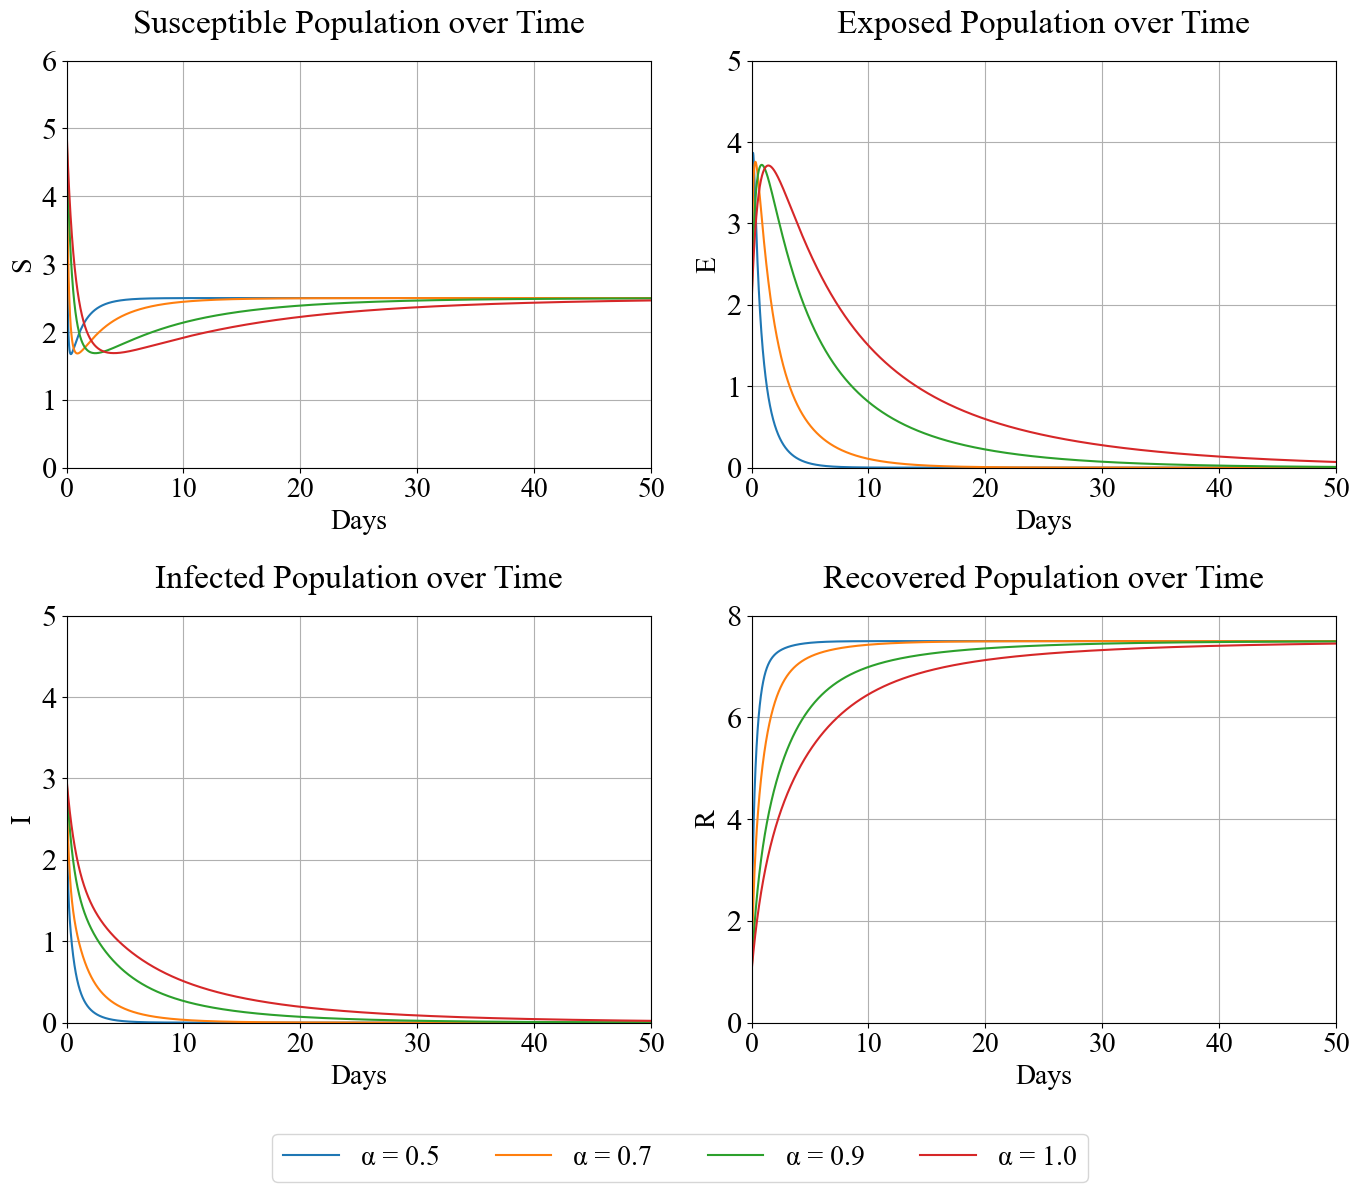

In [ ]:
time_points = t[1:]

figure, axis = plt.subplots(2, 2, figsize=(14, 12))
plt.rcParams.update({'font.size': 20})

for alpha, S_values in S2_values_by_alpha.items():
    axis[0, 0].plot(time_points, S_values, label =  f'{chr(945)} = {alpha}')
    axis[0, 0].set_title(f'Susceptible Population over Time', pad = 20)
    axis[0, 0].set_xlabel('Days', fontsize=20)
    axis[0, 0].set_ylabel('S', fontsize=20)
    axis[0, 0].set_xlim(0,50)
    axis[0, 0].set_ylim(0,6)
    axis[0, 0].grid(True)
    axis[0, 0].tick_params(axis='x', labelsize=20, which='major')

for alpha, E_values in E2_values_by_alpha.items():
    axis[0, 1].plot(time_points, E_values)
    axis[0, 1].set_title(f'Exposed Population over Time', pad = 20)
    axis[0, 1].set_xlabel('Days', fontsize=20)
    axis[0, 1].set_ylabel('E', fontsize=20)
    axis[0, 1].set_xlim(0,50)
    axis[0, 1].set_ylim(0,5)
    axis[0, 1].grid(True)
    axis[0, 1].tick_params(axis='x', labelsize=20, which='major')

for alpha, I_values in I2_values_by_alpha.items():
    axis[1, 0].plot(time_points, I_values)
    axis[1, 0].set_title(f'Infected Population over Time', pad = 20)
    axis[1, 0].set_xlabel('Days', fontsize=20)
    axis[1, 0].set_ylabel('I', fontsize=20)
    axis[1, 0].set_xlim(0,50)
    axis[1, 0].set_ylim(0,5)
    axis[1, 0].grid(True)
    axis[1, 0].tick_params(axis='x', labelsize=20, which='major')

for alpha, R_values in R2_values_by_alpha.items():
    axis[1, 1].plot(time_points, R_values)
    axis[1, 1].set_title(f'Recovered Population over Time', pad = 20)
    axis[1, 1].set_xlabel('Days', fontsize=20)
    axis[1, 1].set_ylabel('R', fontsize=20)
    axis[1, 1].set_xlim(0,50)
    axis[1, 1].set_ylim(0,8)
    axis[1, 1].grid(True)
    axis[1, 1].tick_params(axis='x', labelsize=20, which='major')

# Display Results
figure.legend(bbox_to_anchor=(0.5, 0.00), loc='upper center', ncol=4)
figure.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

In [ ]:
S_0 = Lambda/(mu + gamma_param)
R_0 = Lambda*gamma_param/(mu*(mu + gamma_param))
scriptR_0 = Lambda*beta*delta/((mu + gamma_param)*(mu + delta)*(tau + mu + rho))
print(f'S_0 = {S_0}')
print(f'R_0 = {R_0}')
print(f'P_0 = ({S_0}, 0, 0, {R_0})')
print(f'scriptR_0 = {scriptR_0}')

S_0 = 2.5
R_0 = 7.499999999999998
P_0 = (2.5, 0, 0, 7.499999999999998)
scriptR_0 = 0.7142857142857142


## Parameter (ii)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# Parameter Value
Lambda = 1
mu = 0.1
beta = 0.3
gamma_param = 0.2
delta = 0.2
tau = 0.2
rho = 0.01

# Fractional orders
alpha_values = [0.5, 0.7, 0.9, 1.0]

h = 0.01  # Time step size
num_steps = 10000

### EFORK (Explicit Fractional Order Runge-Kutta) Method of Order 2α

In [ ]:
# SEIR model
def f1(t, S2, E2, I2, R2):
    return Lambda - (mu + gamma_param)*S2 - beta*S2*I2 + rho*I2

def f2(t, S2, E2, I2, R2):
    return beta*S2*I2 - (delta + mu)*E2

def f3(t, S2, E2, I2, R2):
    return delta*E2 - (tau + mu + rho)*I2

def f4(t, S2, E2, I2, R2):
    return gamma_param*S2 + tau*I2 - mu*R2

# Dictionary to store values for each alpha
S2_values_by_alpha = {}
E2_values_by_alpha = {}
I2_values_by_alpha = {}
R2_values_by_alpha = {}

# Simulation loop for each alpha
for alpha in alpha_values:
    c2 = ((gamma(2*alpha + 1))**2/(gamma(3*alpha + 1)*gamma(alpha + 1)))**(1/alpha)
    a21 = ((gamma(2*alpha + 1))**2/(gamma(3*alpha + 1)*gamma(alpha + 1)**2))
    w1 = 1/gamma(alpha + 1) - (gamma(3*alpha + 1)*gamma(alpha + 1)**2)/gamma(2*alpha + 1)**3
    w2 = (gamma(3*alpha + 1)*gamma(alpha + 1)**2)/gamma(2*alpha + 1)**3

    t = np.zeros(num_steps)
    S2 = np.zeros(num_steps)
    E2 = np.zeros(num_steps)
    I2 = np.zeros(num_steps)
    R2 = np.zeros(num_steps)

    # Initial Conditions
    t[0] = 0
    S2[0] = 5
    E2[0] = 2
    I2[0] = 3
    R2[0] = 1

    # EFORK method
    for k in range(num_steps - 1):

        k1s = h**alpha*f1(t[k], S2[k], E2[k], I2[k], R2[k])
        k1e = h**alpha*f2(t[k], S2[k], E2[k], I2[k], R2[k])
        k1i = h**alpha*f3(t[k], S2[k], E2[k], I2[k], R2[k])
        k1r = h**alpha*f4(t[k], S2[k], E2[k], I2[k], R2[k])

        k2s = h**alpha*f1(t[k] + c2*h, S2[k] + a21*k1s, E2[k], I2[k], R2[k])
        k2e = h**alpha*f2(t[k] + c2*h, S2[k], E2[k] + a21*k1e, I2[k], R2[k])
        k2i = h**alpha*f3(t[k] + c2*h, S2[k], E2[k], I2[k] + a21*k1i, R2[k])
        k2r = h**alpha*f4(t[k] + c2*h, S2[k], E2[k], I2[k], R2[k] + a21*k1r)

        # Numerical Solution
        S2[k + 1] = S2[k] + w1 * k1s + w2 * k2s
        E2[k + 1] = E2[k] + w1 * k1e + w2 * k2e
        I2[k + 1] = I2[k] + w1 * k1i + w2 * k2i
        R2[k + 1] = R2[k] + w1 * k1r + w2 * k2r
        t[k + 1] = t[k] + h

    # Store the solution values for the current alpha
    S2_values_by_alpha[alpha] = S2[1:]
    E2_values_by_alpha[alpha] = E2[1:]
    I2_values_by_alpha[alpha] = I2[1:]
    R2_values_by_alpha[alpha] = R2[1:]

### Results

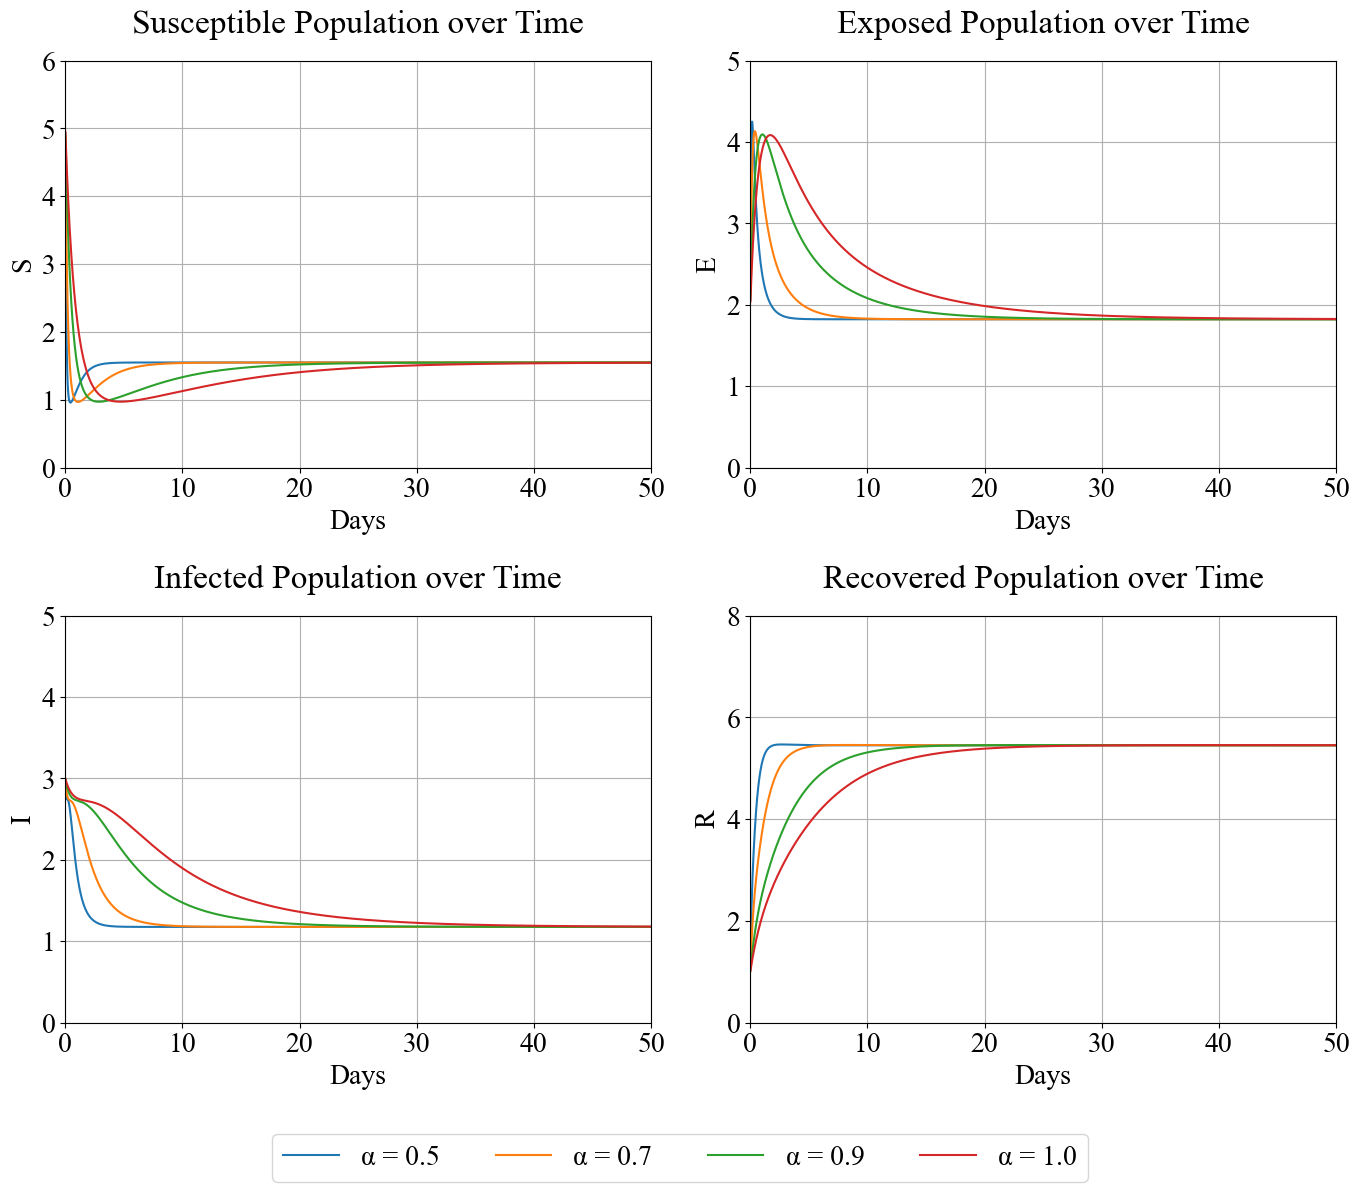

In [ ]:
time_points = t[1:]

figure, axis = plt.subplots(2, 2, figsize=(14, 12))
plt.rcParams.update({'font.size': 20})

for alpha, S_values in S2_values_by_alpha.items():
    axis[0, 0].plot(time_points, S_values, label =  f'{chr(945)} = {alpha}')
    axis[0, 0].set_title(f'Susceptible Population over Time', pad = 20)
    axis[0, 0].set_xlabel('Days', fontsize=20)
    axis[0, 0].set_ylabel('S', fontsize=20)
    axis[0, 0].set_xlim(0,50)
    axis[0, 0].set_ylim(0,6)
    axis[0, 0].grid(True)
    axis[0, 0].tick_params(axis='x', labelsize=20, which='major')

for alpha, E_values in E2_values_by_alpha.items():
    axis[0, 1].plot(time_points, E_values)
    axis[0, 1].set_title(f'Exposed Population over Time', pad = 20)
    axis[0, 1].set_xlabel('Days', fontsize=20)
    axis[0, 1].set_ylabel('E', fontsize=20)
    axis[0, 1].set_xlim(0,50)
    axis[0, 1].set_ylim(0,5)
    axis[0, 1].grid(True)
    axis[0, 1].tick_params(axis='x', labelsize=20, which='major')

for alpha, I_values in I2_values_by_alpha.items():
    axis[1, 0].plot(time_points, I_values)
    axis[1, 0].set_title(f'Infected Population over Time', pad = 20)
    axis[1, 0].set_xlabel('Days', fontsize=20)
    axis[1, 0].set_ylabel('I', fontsize=20)
    axis[1, 0].set_xlim(0,50)
    axis[1, 0].set_ylim(0,5)
    axis[1, 0].grid(True)
    axis[1, 0].tick_params(axis='x', labelsize=20, which='major')

for alpha, R_values in R2_values_by_alpha.items():
    axis[1, 1].plot(time_points, R_values)
    axis[1, 1].set_title(f'Recovered Population over Time', pad = 20)
    axis[1, 1].set_xlabel('Days', fontsize=20)
    axis[1, 1].set_ylabel('R', fontsize=20)
    axis[1, 1].set_xlim(0,50)
    axis[1, 1].set_ylim(0,8)
    axis[1, 1].grid(True)
    axis[1, 1].tick_params(axis='x', labelsize=20, which='major')

# Display Results
figure.legend(bbox_to_anchor=(0.5, 0.00), loc='upper center', ncol=4)
figure.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

In [ ]:
S_1 = (delta + mu)*(tau + mu + rho)/(beta*delta)
I_1 = (Lambda*beta*delta - (mu + gamma_param)*(delta + mu)*(tau + mu + rho))/(beta*(delta + mu)*(tau + mu + rho) - beta*rho*delta)
E_1 = (tau + mu + rho)*I_1/delta
R_1 = (gamma_param*S_1 + tau*I_1)/mu
scriptR_0 = Lambda*beta*delta/((mu + gamma_param)*(mu + delta)*(tau + mu + rho))
print(f'S_1 = {S_1}')
print(f'E_1 = {E_1}')
print(f'I_1 = {I_1}')
print(f'R_1 = {R_1}')
print(f'P_0 = ({S_1}, {E_1}, {I_1}, {R_1})')
print(f'scriptR_0 = {scriptR_0}')

S_1 = 1.5500000000000005
E_1 = 1.8225274725274714
I_1 = 1.175824175824175
R_1 = 5.45164835164835
P_0 = (1.5500000000000005, 1.8225274725274714, 1.175824175824175, 5.45164835164835)
scriptR_0 = 2.150537634408601


## Parameter (iii)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

# Parameter Value
Lambda = 1
mu = 0.1
beta = 0.5
gamma_param = 0.2
delta = 0.3
tau = 0.4
alpha = 0.5

# Clearance Rate (omega)
rho_values = [0.2, 0.5, 0.8]

h = 0.01  # Time step size
num_steps = 10000

### EFORK (Explicit Fractional Order Runge-Kutta) Method of Order 2α

In [ ]:
# SEIR model
def f1(t, S2, E2, I2, R2):
    return Lambda - (mu + gamma_param)*S2 - beta*S2*I2 + rho*I2

def f2(t, S2, E2, I2, R2):
    return beta*S2*I2 - (delta + mu)*E2

def f3(t, S2, E2, I2, R2):
    return delta*E2 - (tau + mu + rho)*I2

def f4(t, S2, E2, I2, R2):
    return gamma_param*S2 + tau*I2 - mu*R2

# Dictionary to store values for each alpha
S2_values_by_rho = {}
E2_values_by_rho = {}
I2_values_by_rho = {}
R2_values_by_rho = {}

# Simulation loop for each alpha
for rho in rho_values:
    c2 = ((gamma(2*alpha + 1))**2/(gamma(3*alpha + 1)*gamma(alpha + 1)))**(1/alpha)
    a21 = ((gamma(2*alpha + 1))**2/(gamma(3*alpha + 1)*gamma(alpha + 1)**2))
    w1 = 1/gamma(alpha + 1) - (gamma(3*alpha + 1)*gamma(alpha + 1)**2)/gamma(2*alpha + 1)**3
    w2 = (gamma(3*alpha + 1)*gamma(alpha + 1)**2)/gamma(2*alpha + 1)**3

    t = np.zeros(num_steps)
    S2 = np.zeros(num_steps)
    E2 = np.zeros(num_steps)
    I2 = np.zeros(num_steps)
    R2 = np.zeros(num_steps)

    # Initial Conditions
    t[0] = 0
    S2[0] = 5
    E2[0] = 2
    I2[0] = 3
    R2[0] = 1

    # EFORK method
    for k in range(num_steps - 1):

        k1s = h**alpha*f1(t[k], S2[k], E2[k], I2[k], R2[k])
        k1e = h**alpha*f2(t[k], S2[k], E2[k], I2[k], R2[k])
        k1i = h**alpha*f3(t[k], S2[k], E2[k], I2[k], R2[k])
        k1r = h**alpha*f4(t[k], S2[k], E2[k], I2[k], R2[k])

        k2s = h**alpha*f1(t[k] + c2*h, S2[k] + a21*k1s, E2[k], I2[k], R2[k])
        k2e = h**alpha*f2(t[k] + c2*h, S2[k], E2[k] + a21*k1e, I2[k], R2[k])
        k2i = h**alpha*f3(t[k] + c2*h, S2[k], E2[k], I2[k] + a21*k1i, R2[k])
        k2r = h**alpha*f4(t[k] + c2*h, S2[k], E2[k], I2[k], R2[k] + a21*k1r)

        # Numerical Solution
        S2[k + 1] = S2[k] + w1 * k1s + w2 * k2s
        E2[k + 1] = E2[k] + w1 * k1e + w2 * k2e
        I2[k + 1] = I2[k] + w1 * k1i + w2 * k2i
        R2[k + 1] = R2[k] + w1 * k1r + w2 * k2r
        t[k + 1] = t[k] + h

    # Store the solution values for the current omega
    S2_values_by_rho[rho] = S2[1:]
    E2_values_by_rho[rho] = E2[1:]
    I2_values_by_rho[rho] = I2[1:]
    R2_values_by_rho[rho] = R2[1:]

### Results

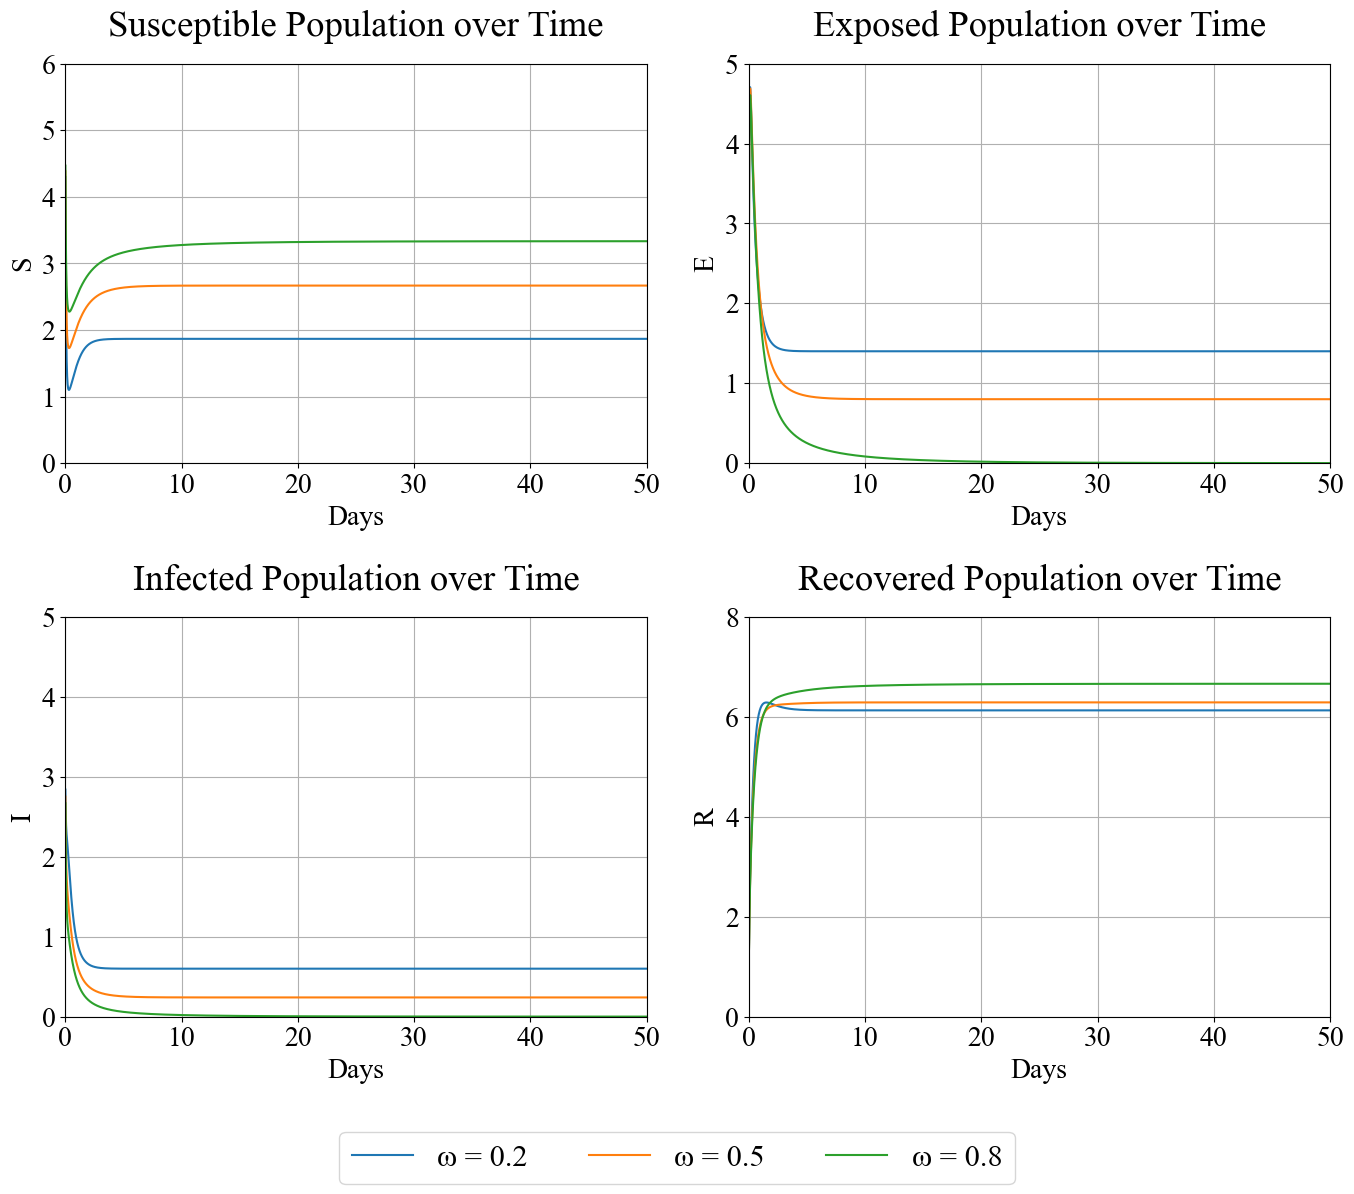

In [ ]:
time_points = t[1:]

figure, axis = plt.subplots(2, 2, figsize=(14, 12))
plt.rcParams.update({'font.size': 22})

for alpha, S_values in S2_values_by_rho.items():
    axis[0, 0].plot(time_points, S_values, label =  f'{chr(969)} = {alpha}')
    axis[0, 0].set_title(f'Susceptible Population over Time', pad = 20)
    axis[0, 0].set_xlabel('Days', fontsize=20)
    axis[0, 0].set_ylabel('S', fontsize=20)
    axis[0, 0].set_xlim(0,50)
    axis[0, 0].set_ylim(0,6)
    axis[0, 0].grid(True)
    axis[0, 0].tick_params(axis='x', labelsize=20, which='major')

for alpha, E_values in E2_values_by_rho.items():
    axis[0, 1].plot(time_points, E_values)
    axis[0, 1].set_title(f'Exposed Population over Time', pad = 20)
    axis[0, 1].set_xlabel('Days', fontsize=20)
    axis[0, 1].set_ylabel('E', fontsize=20)
    axis[0, 1].set_xlim(0,50)
    axis[0, 1].set_ylim(0,5)
    axis[0, 1].grid(True)
    axis[0, 1].tick_params(axis='x', labelsize=20, which='major')

for alpha, I_values in I2_values_by_rho.items():
    axis[1, 0].plot(time_points, I_values)
    axis[1, 0].set_title(f'Infected Population over Time', pad = 20)
    axis[1, 0].set_xlabel('Days', fontsize=20)
    axis[1, 0].set_ylabel('I', fontsize=20)
    axis[1, 0].set_xlim(0,50)
    axis[1, 0].set_ylim(0,5)
    axis[1, 0].grid(True)
    axis[1, 0].tick_params(axis='x', labelsize=20, which='major')

for alpha, R_values in R2_values_by_rho.items():
    axis[1, 1].plot(time_points, R_values)
    axis[1, 1].set_title(f'Recovered Population over Time', pad = 20)
    axis[1, 1].set_xlabel('Days', fontsize=20)
    axis[1, 1].set_ylabel('R', fontsize=20)
    axis[1, 1].set_xlim(0,50)
    axis[1, 1].set_ylim(0,8)
    axis[1, 1].grid(True)
    axis[1, 1].tick_params(axis='x', labelsize=20, which='major')

# Display Results
figure.legend(bbox_to_anchor=(0.5, 0.00), loc='upper center', ncol=4)
figure.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
rho = 0.2
S_1 = (delta + mu)*(tau + mu + rho)/(beta*delta)
I_1 = (Lambda*beta*delta - (mu + gamma_param)*(delta + mu)*(tau + mu + rho))/(beta*(delta + mu)*(tau + mu + rho) - beta*rho*delta)
E_1 = (tau + mu + rho)*I_1/delta
R_1 = (gamma_param*S_1 + tau*I_1)/mu
scriptR_0 = Lambda*beta*delta/((mu + gamma_param)*(mu + delta)*(tau + mu + rho))
print(f'S_1 = {S_1}')
print(f'E_1 = {E_1}')
print(f'I_1 = {I_1}')
print(f'R_1 = {R_1}')
print(f'P_1 = ({S_1}, {E_1}, {I_1}, {R_1})')
print(f'scriptR_0 = {scriptR_0}')

S_1 = 1.8666666666666665
E_1 = 1.4
I_1 = 0.6
R_1 = 6.133333333333333
P_1 = (1.8666666666666665, 1.4, 0.6, 6.133333333333333)
scriptR_0 = 1.7857142857142856


In [ ]:
rho = 0.5
S_1 = (delta + mu)*(tau + mu + rho)/(beta*delta)
I_1 = (Lambda*beta*delta - (mu + gamma_param)*(delta + mu)*(tau + mu + rho))/(beta*(delta + mu)*(tau + mu + rho) - beta*rho*delta)
E_1 = (tau + mu + rho)*I_1/delta
R_1 = (gamma_param*S_1 + tau*I_1)/mu
scriptR_0 = Lambda*beta*delta/((mu + gamma_param)*(mu + delta)*(tau + mu + rho))
print(f'S_1 = {S_1}')
print(f'E_1 = {E_1}')
print(f'I_1 = {I_1}')
print(f'R_1 = {R_1}')
print(f'P_0 = ({S_1}, {E_1}, {I_1}, {R_1})')
print(f'scriptR_0 = {scriptR_0}')

S_1 = 2.666666666666667
E_1 = 0.7999999999999993
I_1 = 0.23999999999999977
R_1 = 6.293333333333333
P_0 = (2.666666666666667, 0.7999999999999993, 0.23999999999999977, 6.293333333333333)
scriptR_0 = 1.2499999999999998


In [ ]:
rho = 0.8
S_0 = Lambda/(mu + gamma_param)
E_0 = 0
I_0 = 0
R_0 = Lambda*gamma_param/(mu*(mu + gamma_param))
scriptR_0 = Lambda*beta*delta/((mu + gamma_param)*(mu + delta)*(tau + mu + rho))
print(f'S_0 = {S_0}')
print(f'E_0 = {E_0}')
print(f'I_0 = {I_0}')
print(f'R_0 = {R_0}')
print(f'P_0 = ({S_0}, {E_0}, {I_0}, {R_0})')
print(f'scriptR_0 = {scriptR_0}')

S_0 = 3.333333333333333
E_0 = 0
I_0 = 0
R_0 = 6.666666666666666
P_0 = (3.333333333333333, 0, 0, 6.666666666666666)
scriptR_0 = 0.9615384615384613
